# Student Performance Analysis and Prediction

In this project, we will perform Exploratory Data Analysis (EDA) and build a regression model to predict the students performance index based on variables such as study hours, previous scores, and sleep hours.

## 1. Importing Libraries and Data Collection

In [1]:
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()

dataset = "nikhil7280/student-performance-multiple-linear-regression"
api.dataset_download_files(dataset, path=".", unzip=True)

Dataset URL: https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression


In [2]:
from pathlib import Path
import shutil as sh
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Directory Organization and Loading
To keep the workspace organized, we will create separate directories to store the raw data (`DataSets`). Then, we will move the downloaded file to the correct folder.

In [3]:
datasets = Path ('DataSets')
datasets.mkdir(exist_ok=True)

In [4]:
raw_dataset = Path('Student_Performance.csv')
if raw_dataset.exists():
    sh.move(raw_dataset, datasets / "Student_Performance_Raw.csv")
raw_dataset = Path('Student_Performance_Raw.csv') # Delets the archive that is in the root
if raw_dataset.exists():
    raw_dataset.unlink()

In [5]:
archive = datasets / "Student_Performance_Raw.csv"
if archive.exists():
    dataframe = pd.read_csv('DataSets/Student_Performance_Raw.csv')


## 3. Exploratory Data Analysis (EDA)
We will inspect the first rows of our dataset to understand its structure, check the data types present, and analyze the statistical summary of the numerical variables.

In [6]:
dataframe.head(n=10)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
5,3,78,No,9,6,61.0
6,7,73,Yes,5,6,63.0
7,8,45,Yes,4,6,42.0
8,5,77,No,8,2,61.0
9,4,89,No,4,0,69.0


In [7]:
dataframe.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  str    
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), str(1)
memory usage: 468.9 KB


In [8]:
dataframe.describe().T

,count,mean,std,min,25%,50%,75%,max
Hours Studied,10000.0,4.9929,2.589309,1.0,3.0,5.0,7.0,9.0
Previous Scores,10000.0,69.4457,17.343152,40.0,54.0,69.0,85.0,99.0
Sleep Hours,10000.0,6.5306,1.695863,4.0,5.0,7.0,8.0,9.0
Sample Question Papers Practiced,10000.0,4.5833,2.867348,0.0,2.0,5.0,7.0,9.0
Performance Index,10000.0,55.2248,19.212558,10.0,40.0,55.0,71.0,100.0


### 3.1. Handling Missing Values
Check if the dataset has any missing values (NaN) that would need to be handled prior to modeling.

In [9]:
dataframe.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

## 4. Data Preprocessing
Mathematical models require numerical data. The `Extracurricular Activities` column is categorical (Yes/No). We will convert it to a boolean/numerical format using *One-Hot Encoding* (`pd.get_dummies`) and rearrange the columns for better readability.

In [10]:
dataframe_dummies = pd.get_dummies(dataframe['Extracurricular Activities'], drop_first=True)
dataframe = pd.concat([dataframe, dataframe_dummies], axis=1)
dataframe.drop(['Extracurricular Activities'], axis=1, inplace=True)
dataframe.rename(columns={'Yes':'Extracurricular Activities','Performance Index' : 'Performance' }, inplace=True)

dataframe

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance,Extracurricular Activities
0,7,99,9,1,91.0,True
1,4,82,4,2,65.0,False
2,8,51,7,2,45.0,True
3,5,52,5,2,36.0,True
4,7,75,8,5,66.0,False
...,...,...,...,...,...,...
9995,1,49,4,2,23.0,True
9996,7,64,8,5,58.0,True
9997,6,83,8,5,74.0,True
9998,9,97,7,0,95.0,True


In [11]:
dataframe = dataframe[['Hours Studied', 'Previous Scores', 'Sleep Hours',
                       'Sample Question Papers Practiced', 'Extracurricular Activities',
                       'Performance']]
dataframe

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Extracurricular Activities,Performance
0,7,99,9,1,True,91.0
1,4,82,4,2,False,65.0
2,8,51,7,2,True,45.0
3,5,52,5,2,True,36.0
4,7,75,8,5,False,66.0
...,...,...,...,...,...,...
9995,1,49,4,2,True,23.0
9996,7,64,8,5,True,58.0
9997,6,83,8,5,True,74.0
9998,9,97,7,0,True,95.0


## 5. Data Visualization
Below, we will create plots to visualize how the independent variables affect the performance index (`Performance`).

**Hours Studied vs. Performance:** The boxplot helps us observe the distribution of scores based on the amount of hours the students dedicated to studying.

Text(0.5, 1.0, 'Hours Studied x Performance')

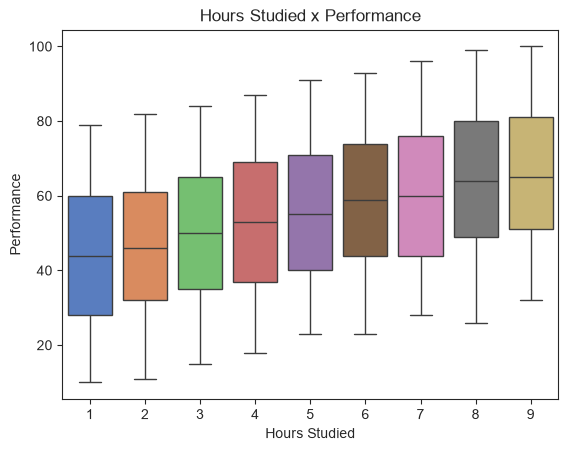

In [12]:
sns.set_style('ticks')
fig,ax = plt.subplots()
sns.boxplot(data = dataframe,
            ax=ax,
            x= 'Hours Studied',
            y='Performance',
            palette= 'muted',
            hue = 'Hours Studied',
            legend=False)
ax.set_title("Hours Studied x Performance")

**Previous Scores vs. Performance:** The scatterplot illustrates the correlation between the student's historical grades and their current performance, usually showing a strong positive trend.

Text(0.5, 1.0, 'Previous Scores x Performance')

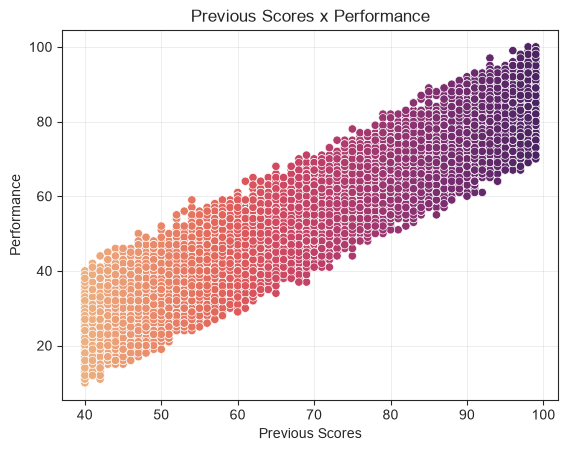

In [13]:
fig,ax = plt.subplots()
ax.grid()
sns.scatterplot(data = dataframe,
                ax=ax,
                x = 'Previous Scores',
                y = 'Performance',
                hue = 'Previous Scores',
                legend=False,
                palette= 'flare')
ax.set_title("Previous Scores x Performance")


**Correlation Matrix:** A heatmap is an excellent tool to visualize the correlation coefficients between all numerical variables in the dataset. It helps us identify which features have the strongest linear relationship with our target variable (`Performance`), as well as check for multicollinearity between independent variables.

Text(0.5, 1.0, 'Correlation Matrix')

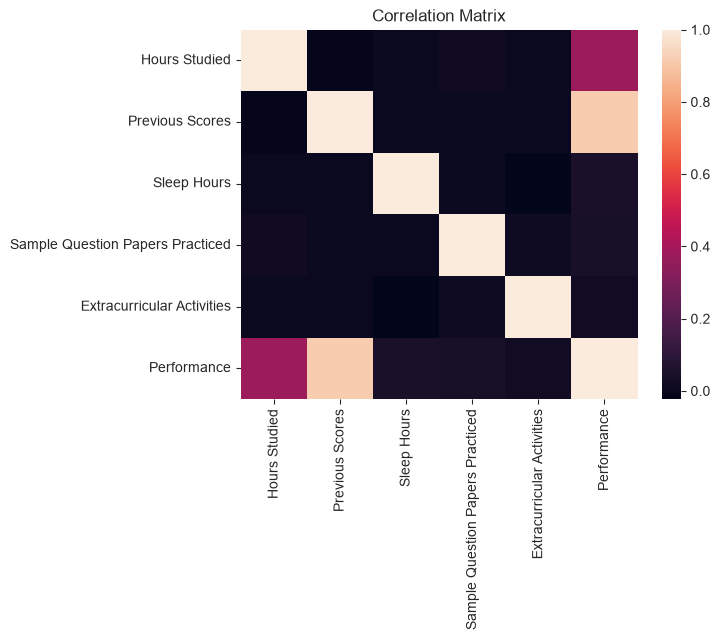

In [14]:
fig,ax = plt.subplots()
sns.heatmap(dataframe.corr(), ax=ax)

ax.set_title("Correlation Matrix")

**Target Variable Distribution:** Let's look at the distribution of our target variable, `Performance`. A histogram will show us the frequency of the scores and help us understand if the data is normally distributed.

Text(0.5, 1.0, 'Performance distribution')

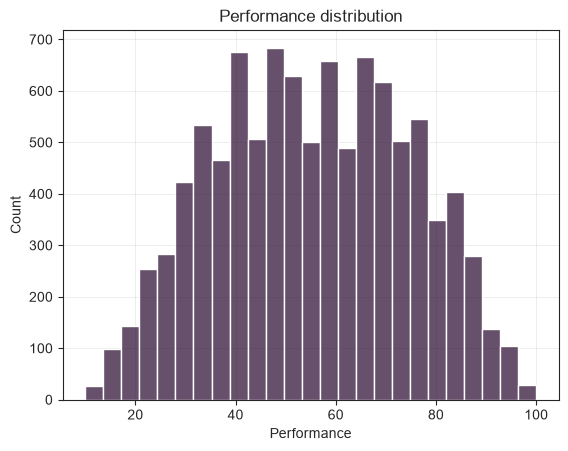

In [15]:
fig,ax = plt.subplots()
sns.histplot(data = dataframe,
            x='Performance',
            color="#341539",
            fill = True,
            ax=ax,
            bins=25,
            )
ax.grid()
ax.set_title("Performance distribution")


## Machine Learning
Using linear based models to predict the overall performance of the students

In [16]:
X = dataframe.drop('Performance', axis=1)
y = dataframe['Performance']

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, lasso_path
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

## 6. Model Selection: Finding the Optimal Polynomial Degree
Before training our final model, we will evaluate polynomial regression models of various degrees (from 1 to 9) to see if adding complexity yields better results. We will plot the Root Mean Squared Error (RMSE) for both the training and test datasets to identify potential overfitting and choose the most suitable polynomial degree.

In [ ]:
error_train = []
error_test= []

for i in range (1,10):
    polynomial_converter = PolynomialFeatures(degree=i, include_bias=False)
    X_poly = polynomial_converter.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.25, random_state=42)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = LinearRegression()
    model.fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))

    error_train.append(rmse_train)
    error_test.append(rmse_test)

plt.figure(figsize=(8, 5))
plt.grid
plt.plot(range (1,10), error_train, label='Error in training data', marker='o')
plt.plot(range(1,10), error_test, label='Error in test data', marker='o')
plt.xlabel('degree of the polynomial')
plt.ylabel('RMSE')
plt.title('Error vs. degree of the polynomial')
plt.legend()

## 7. Simple Linear Regression
As observed in the previous plot, a polynomial of degree 1 (Simple Linear Regression) proves to be the most appropriate for this context, avoiding unnecessary complexity and overfitting.

Now, we will scale our features using `StandardScaler`, fit the linear model, and evaluate its performance using metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE).

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
model.coef_

In [ ]:
pred_test = model.predict(X_test)

print(f'Mean_absolute_error: {np.round(mean_absolute_error(y_test, pred_test), 2)} \n'
      f'Mean_squared_error: {np.round(mean_squared_error(y_test, pred_test), 2)} \n'
      f'Root_Mean_squared_error: {np.round(np.sqrt(mean_squared_error(y_test, pred_test)), 2)}')

## 8. Regularization: Lasso and Ridge Regression
To ensure our model is robust and to test if we can minimize the error further, we will apply L1 (Lasso) and L2 (Ridge) regularization techniques. We will use `GridSearchCV` to test multiple candidates and find the optimal hyperparameter (`alpha`) for each model using cross-validation.

In [ ]:
lasso_model = Lasso()

grid_params = [{'alpha': np.logspace(-4, 1, 100)}]
grid_lasso_model = GridSearchCV(lasso_model, grid_params, cv=10, scoring='neg_mean_squared_error',verbose=1)
grid_lasso_model.fit(X_train, y_train)

In [ ]:
print(f'grid parameters: {grid_lasso_model.best_params_['alpha']} \n'
      f'grid best score: {grid_lasso_model.best_score_} \n'
      f'Betha coefficients : {grid_lasso_model.best_estimator_.coef_}')

In [ ]:
pred_test = grid_lasso_model.predict(X_test)

print(f'Mean_absolute_error: {np.round(mean_absolute_error(y_test, pred_test), 2)} \n'
      f'Mean_squared_error: {np.round(mean_squared_error(y_test, pred_test), 2)} \n'
      f'Root_Mean_squared_error: {np.round(np.sqrt(mean_squared_error(y_test, pred_test)), 2)}')

In [ ]:
ridge_model = Ridge()

grid_params = [{'alpha': np.logspace(-3, 3, 100)}]
grid_ridge_model = GridSearchCV(ridge_model, grid_params, cv=10, scoring='neg_mean_squared_error',verbose=1)
grid_ridge_model.fit(X_train, y_train)

In [ ]:
print(f'grid parameters: {grid_ridge_model.best_params_['alpha']} \n'
      f'grid best score: {grid_ridge_model.best_score_} \n'
      f'Betha coefficients : {grid_ridge_model.best_estimator_.coef_}')

In [ ]:
pred_test = grid_ridge_model.predict(X_test)

print(f'Mean_absolute_error: {np.round(mean_absolute_error(y_test, pred_test), 2)} \n'
      f'Mean_squared_error: {np.round(mean_squared_error(y_test, pred_test), 2)} \n'
      f'Root_Mean_squared_error: {np.round(np.sqrt(mean_squared_error(y_test, pred_test)), 2)}')

*Note: Because the optimal alpha chosen by the GridSearch is very small, the Lasso regression and Ridge regression behaves practically like a standard linear regression model.*